In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Replace '?' with NaN
train_df.replace("?", np.nan, inplace=True)
test_df.replace("?", np.nan, inplace=True)

train_df.head()


,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,C-36995,Frederica Shealy,F,56,1933.05,Low,Working,Sales staff,Semi-Urban,72809.58,...,809.44,0,NaN,746,1933.05,4,Rural,1,119933.46,54607.18
1,C-33999,America Calderone,M,32,4952.91,Low,Working,NaN,Semi-Urban,46837.47,...,780.40,0,Unpossessed,608,4952.91,2,Rural,1,54791.00,37469.98
2,C-3770,Rosetta Verne,F,65,988.19,High,Pensioner,NaN,Semi-Urban,45593.04,...,833.15,0,Unpossessed,546,988.19,2,Urban,0,72440.58,36474.43
3,C-26480,Zoe Chitty,F,65,NaN,High,Pensioner,NaN,Rural,80057.92,...,832.70,1,Unpossessed,890,NaN,2,Semi-Urban,1,121441.51,56040.54
4,C-23459,Afton Venema,F,31,2614.77,Low,Working,High skill tech staff,Semi-Urban,113858.89,...,745.55,1,Active,715,2614.77,4,Semi-Urban,1,208567.91,74008.28


In [3]:
id_cols = ["Customer ID", "Name", "Property ID"]
train_df.drop(columns=id_cols, inplace=True, errors="ignore")
test_df.drop(columns=id_cols, inplace=True, errors="ignore")


In [4]:
train_df = train_df.dropna()
test_df = test_df.dropna()


In [5]:
target = "Loan Amount Request (USD)"

drop_cols = [
    "Loan Amount Request (USD)",
    "Loan Sanction Amount (USD)"  # if exists
]

X_train = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
y_train = train_df[target]

X_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])
y_test = test_df[target]


In [6]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


categorical_cols = X_train.select_dtypes(include=["object"]).columns
numerical_cols = X_train.select_dtypes(exclude=["object"]).columns


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


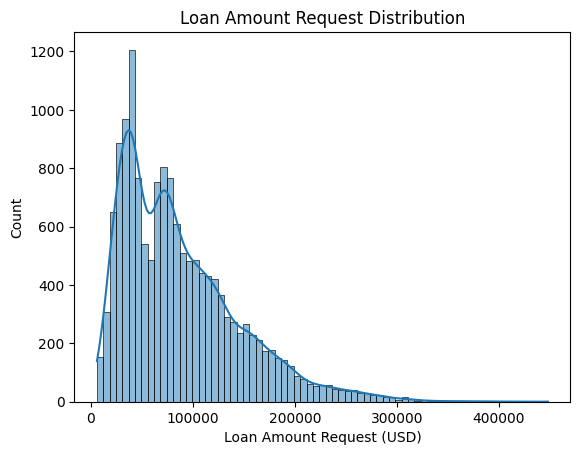

In [8]:
sns.histplot(y_train, kde=True)
plt.title("Loan Amount Request Distribution")
plt.show()


In [9]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [10]:
y_pred_lr = linear_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

mae_lr, mse_lr, rmse_lr, r2_lr


(10924.033122268076,
 226727756.91094133,
 np.float64(15057.481758612272),
 0.9327151051392742)

In [11]:
ridge = Pipeline([
    ("preprocess", preprocessor),
    ("model", Ridge())
])

ridge_params = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_search = GridSearchCV(
    ridge, ridge_params, cv=5, scoring="r2"
)

ridge_search.fit(X_train, y_train)
ridge_search.best_params_


{'model__alpha': 0.01}

In [19]:
lasso = Pipeline([
    ("preprocess", preprocessor),
    ("model", Lasso(max_iter=5000))
])

lasso_params = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10]
}

lasso_search = GridSearchCV(
    lasso, lasso_params, cv=5, scoring="r2"
)

lasso_search.fit(X_train, y_train)
lasso_search.best_params_


{'model__alpha': 50}

In [13]:
elastic = Pipeline([
    ("preprocess", preprocessor),
    ("model", ElasticNet(max_iter=5000))
])

elastic_params = {
    "model__alpha": [0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.2, 0.5, 0.8]
}

elastic_search = GridSearchCV(
    elastic, elastic_params, cv=5, scoring="r2"
)

elastic_search.fit(X_train, y_train)
elastic_search.best_params_


{'model__alpha': 0.01, 'model__l1_ratio': 0.8}

In [14]:
def evaluate(model):
    y_pred = model.predict(X_test)
    return {
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    }


In [15]:
results = pd.DataFrame({
    "Linear": evaluate(linear_model),
    "Ridge": evaluate(ridge_search.best_estimator_),
    "Lasso": evaluate(lasso_search.best_estimator_),
    "ElasticNet": evaluate(elastic_search.best_estimator_)
})

results


,Linear,Ridge,Lasso,ElasticNet
MAE,1.092403e+04,1.092403e+04,1.091884e+04,1.092850e+04
MSE,2.267278e+08,2.267278e+08,2.265570e+08,2.268475e+08
RMSE,1.505748e+04,1.505748e+04,1.505181e+04,1.506146e+04
R2,9.327151e-01,9.327151e-01,9.327658e-01,9.326796e-01


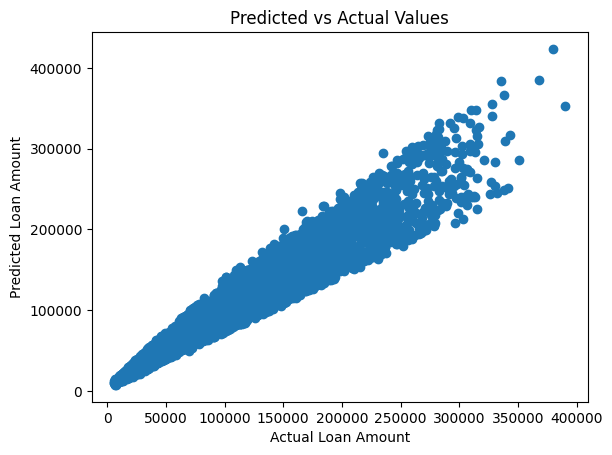

In [16]:
plt.scatter(y_test, ridge_search.best_estimator_.predict(X_test))
plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Predicted vs Actual Values")
plt.show()


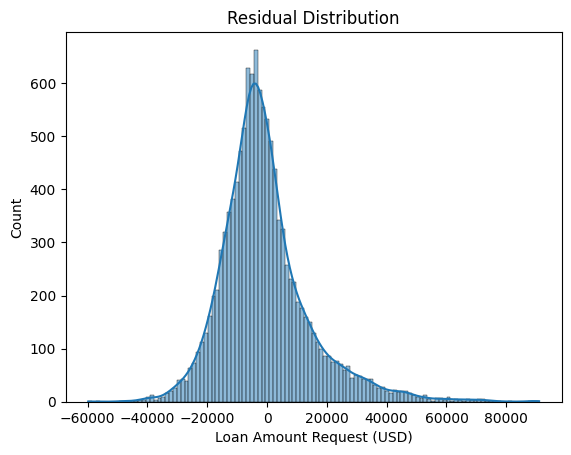

In [17]:
residuals = y_test - ridge_search.best_estimator_.predict(X_test)
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


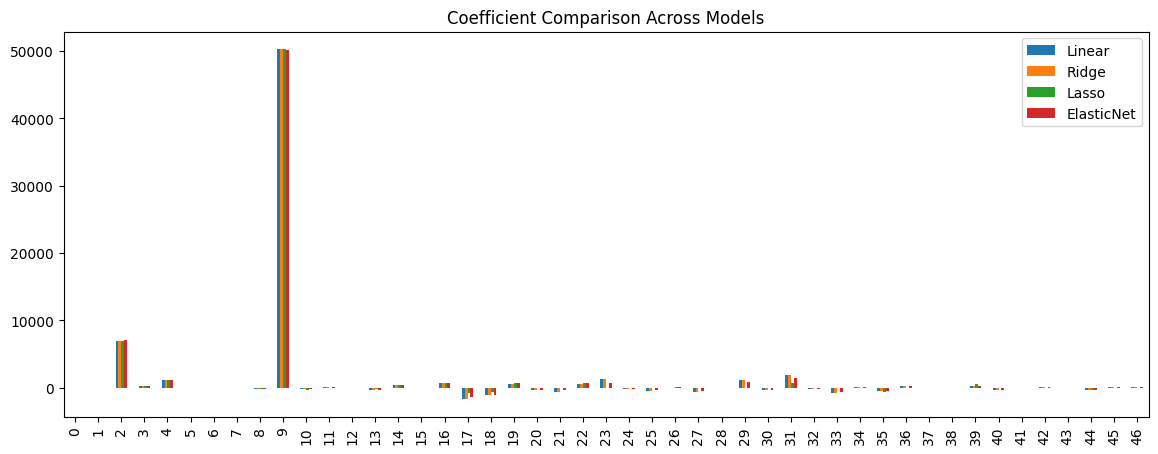

In [18]:
coef_df = pd.DataFrame({
    "Linear": linear_model.named_steps["model"].coef_,
    "Ridge": ridge_search.best_estimator_.named_steps["model"].coef_,
    "Lasso": lasso_search.best_estimator_.named_steps["model"].coef_,
    "ElasticNet": elastic_search.best_estimator_.named_steps["model"].coef_
})

coef_df.plot(kind="bar", figsize=(14,5))
plt.title("Coefficient Comparison Across Models")
plt.show()
